In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets_path = '../datasets.csv'
detection_path = '../detectability/detection_results.csv'
similarity_path = '../cosine-similarity/essay_similarity_results.xlsx'

# Load datasets
df_datasets = pd.read_csv(datasets_path)
df_detection = pd.read_csv(detection_path)

# Read similarity results
df_similarity = pd.read_excel(similarity_path)

print("Datasets loaded successfully.")
print(f"Datasets shape: {df_datasets.shape}")
print(f"Results shape: {df_detection.shape}")
print(f"Similarity shape: {df_similarity.shape}")

Datasets loaded successfully.
Datasets shape: (180, 6)
Results shape: (180, 10)
Similarity shape: (179, 9)


In [35]:
df_datasets.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...


In [36]:
df_detection.head()

,topic,length,AI_model,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,100.0,100.0,100.00,100.0,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,100.0,100.0,100.00,100.0,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,100.0,100.0,79.21,100.0,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,100.0,100.0,100.00,100.0,99.987373,99.995690
4,1,3,gpt4.0,AIHumanizer,100.0,100.0,99.99,100.0,99.990441,99.935826


In [40]:
df_similarity.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
0,1,Short,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,Short,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,Short,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,Short,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,Short,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359


In [41]:
# Drop row that is topic 5, length 2 (medium), gemini2.5pro, writehuman.ai
df_detection = df_detection[~((df_detection['topic'] == 5) & (df_detection['length'] == 2) & (df_detection['AI_model'] == 'gemini2.5pro') & (df_detection['humanizer'] == 'writehuman.ai'))]

df_similarity = df_similarity[~((df_similarity['topic'] == 5) & (df_similarity['length'] == 'Medium') & (df_similarity['AI_model'] == 'gemini2.5pro') & (df_similarity['humanizer'] == 'writehuman.ai'))]

df_datasets = df_datasets[~((df_datasets['topic'] == 5) & (df_datasets['length'] == 2) & (df_datasets['AI_model'] == 'gemini2.5pro') & (df_datasets['humanizer'] == 'writehuman.ai'))]

print("Datasets Updated successfully.")
print(f"Datasets shape: {df_datasets.shape}")
print(f"Results shape: {df_detection.shape}")
print(f"Similarity shape: {df_similarity.shape}")

Datasets Updated successfully.
Datasets shape: (179, 6)
Results shape: (179, 10)
Similarity shape: (179, 9)


In [ ]:
# Map length from string to numeric for matching

df_similarity = df_similarity.copy()

df_similarity['length_num'] = df_similarity['length'].map({
    'Short': 1,
    'Medium': 2,
    'Long': 3
})

df_similarity[['length', 'length_num']].head()


,length,length_num
0,Short,1
1,Short,1
2,Short,1
3,Short,1
4,Short,1


In [46]:
# Prepare data for plotting
plot_rows = []

for _, r in df_similarity.iterrows():
    match = df_detection[
        (df_detection['topic'] == r['topic']) &
        (df_detection['length'] == r['length_num']) &
        (df_detection['AI_model'] == r['AI_model']) &
        (df_detection['humanizer'] == r['humanizer'])
    ]

    if len(match) == 1:
        plot_rows.append({
            'humanizer': r['humanizer'],
            'TFIDF': r['TF-IDF'],
            'SBERT': r['SBERT'],
            'Nemotron': r['Nemotron'],
            'Sapling': match['sapling_humanized'].iloc[0],
            'ZeroGPT': match['zerogpt_humanized'].iloc[0],
            'CopyLeaks': match['copyleaks_humanized'].iloc[0],
        })

plot_df = pd.DataFrame(plot_rows)
plot_df.head()


,humanizer,TFIDF,SBERT,Nemotron,Sapling,ZeroGPT,CopyLeaks
0,AIHumanizer,0.359997,0.850309,0.907571,99.995351,100.00,100.0
1,Grammarly,0.336786,0.754118,0.848066,99.996127,100.00,100.0
2,HumanizeAI,0.502740,0.915031,0.934771,99.843932,0.00,0.0
3,Quillbot,0.505379,0.930350,0.936948,30.721407,64.63,100.0
4,UndetectableAI,0.428381,0.850842,0.844359,99.351209,0.00,0.0


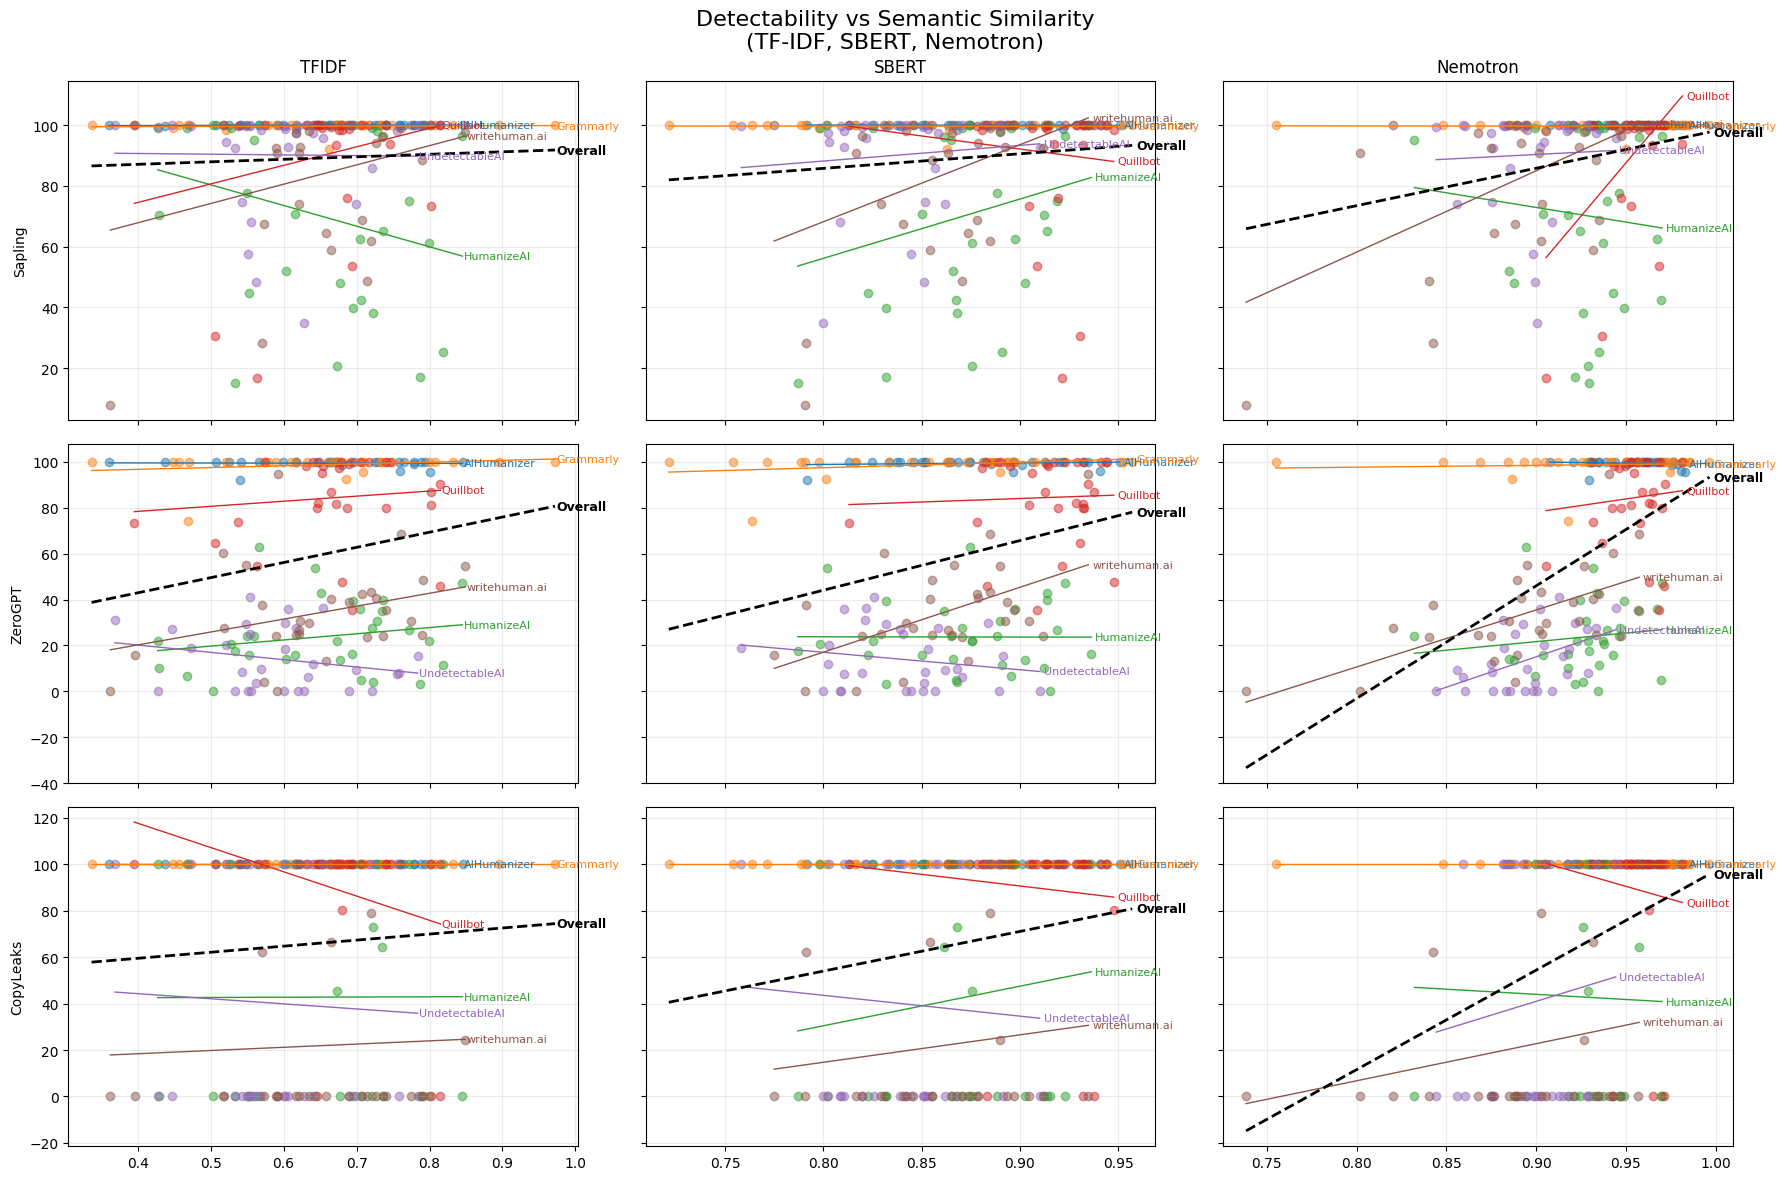

In [49]:
import numpy as np
import matplotlib.pyplot as plt

similarities = ['TFIDF', 'SBERT', 'Nemotron']
detectors = ['Sapling', 'ZeroGPT', 'CopyLeaks']
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(
    nrows=len(detectors),
    ncols=len(similarities),
    figsize=(18, 12),
    sharex='col',
    sharey='row'
)

for i, det in enumerate(detectors):
    for j, sim in enumerate(similarities):
        ax = axes[i, j]

        # Make regression lines per humanizer
        for k, h in enumerate(plot_df['humanizer'].unique()):
            sub = plot_df[plot_df['humanizer'] == h]

            x = sub[sim].values
            y = sub[det].values

            ax.scatter(x, y, alpha=0.5, color=colors[k])

            if len(x) >= 2:
                m, b = np.polyfit(x, y, 1)
                xx = np.linspace(x.min(), x.max(), 100)
                yy = m * xx + b
                ax.plot(xx, yy, color=colors[k], linewidth=1)
                ax.text(
                    xx.max() + 0.002,
                    yy[-1],
                    h,
                    color=colors[k],
                    fontsize=8,
                    va='center'
                )

        # Make overall regression line
        x_all = plot_df[sim].values
        y_all = plot_df[det].values

        if len(x_all) >= 2:
            m_all, b_all = np.polyfit(x_all, y_all, 1)
            xx_all = np.linspace(x_all.min(), x_all.max(), 200)
            yy_all = m_all * xx_all + b_all

            ax.plot(
                xx_all,
                yy_all,
                color='black',
                linestyle='--',
                linewidth=2
            )

            ax.text(
                xx_all.max() + 0.002,
                yy_all[-1],
                'Overall',
                color='black',
                fontsize=9,
                fontweight='bold',
                va='center'
            )

        # Labels and grid
        if i == 0:
            ax.set_title(sim)
        if j == 0:
            ax.set_ylabel(det)

        ax.grid(alpha=0.25)

plt.suptitle(
    "Detectability vs Semantic Similarity\n(TF-IDF, SBERT, Nemotron)",
    fontsize=16
)
plt.tight_layout()
plt.show()


In [50]:
corr_rows = []

for det in detectors:
    for sim in similarities:
        corr = plot_df[[sim, det]].corr().iloc[0, 1]
        corr_rows.append({
            'Detector': det,
            'Similarity': sim,
            'Correlation': corr
        })

corr_df = pd.DataFrame(corr_rows)
corr_df


,Detector,Similarity,Correlation
0,Sapling,TFIDF,0.044074
1,Sapling,SBERT,0.105725
2,Sapling,Nemotron,0.241108
3,ZeroGPT,TFIDF,0.194758
4,ZeroGPT,SBERT,0.262414
5,ZeroGPT,Nemotron,0.529899
6,CopyLeaks,TFIDF,0.063991
7,CopyLeaks,SBERT,0.171991
8,CopyLeaks,Nemotron,0.384101


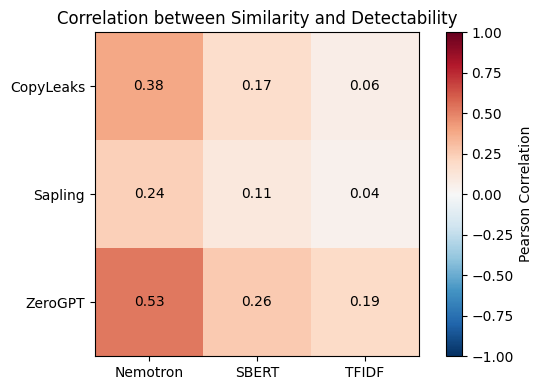

In [51]:
# reshape for heatmap
heatmap_data = corr_df.pivot(
    index='Detector',
    columns='Similarity',
    values='Correlation'
)

plt.figure(figsize=(6,4))
im = plt.imshow(heatmap_data, cmap='RdBu_r', vmin=-1, vmax=1)

plt.colorbar(im, label='Pearson Correlation')

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

# annotate values
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

plt.title("Correlation between Similarity and Detectability")
plt.tight_layout()
plt.show()
